K-means clustering

In [1]:
import mglearn
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [4]:
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('feature_extraction.csv')

In [4]:
df.shape

(3448, 3)

In [7]:
df.head()

,RES_EDU1,RES_MAR,RES_AGE
0,3,3,83
1,5,4,78
2,4,4,67
3,5,3,85
4,1,3,85


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X = pd.DataFrame(X_scaled, columns=df.columns, index=df.index)

In [6]:
X.head()

,RES_EDU1,RES_MAR,RES_AGE
0,-0.286724,-0.362873,1.033370
1,1.171422,1.083584,0.331593
2,0.442349,1.083584,-1.212315
3,1.171422,-0.362873,1.314081
4,-1.744869,-0.362873,1.314081


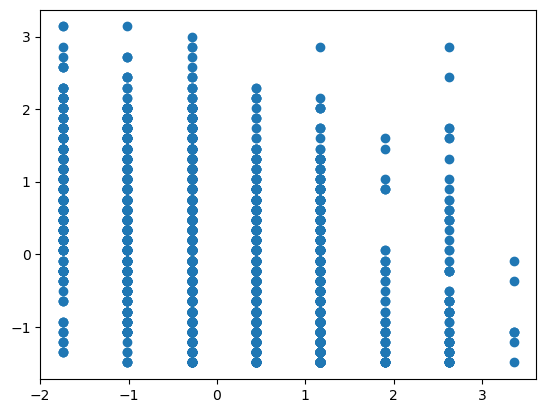

In [25]:
plt.scatter(X.iloc[:,0], X.iloc[:,2])

In [28]:
from mpl_toolkits.mplot3d import Axes3D

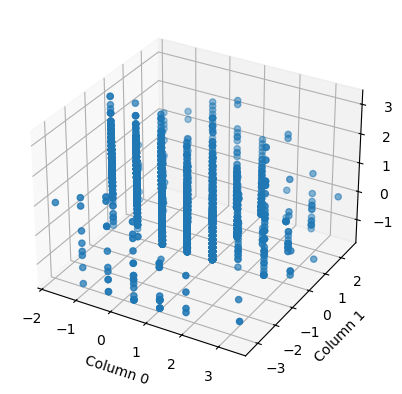

In [29]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X.iloc[:, 0], X.iloc[:, 1], X.iloc[:, 2])  # x, y, z 모두 지정

ax.set_xlabel('Column 0')
ax.set_ylabel('Column 1')
ax.set_zlabel('Column 2')
plt.show()

In [26]:
n_clusters = 4
kmeans = KMeans(n_clusters = n_clusters)
kmeans.fit(X)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [27]:
print(kmeans.cluster_centers_)

[[-0.87676067 -0.36973438  1.14695923]
 [ 0.69629602  1.83351231 -0.72501386]
 [-0.34906345 -0.36287264 -0.24607324]
 [ 1.01609012 -0.49825526 -0.64190537]]


In [30]:
assignments_X_train = kmeans.labels_
print(assignments_X_train)

[0 1 1 ... 3 3 3]


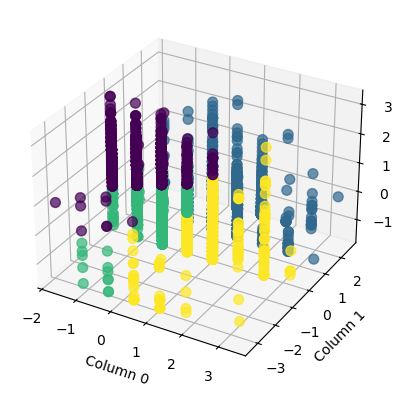

In [32]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X.iloc[:, 0], X.iloc[:, 1], X.iloc[:, 2], c=assignments_X_train, cmap='viridis', s=50, alpha=0.7)  # x, y, z 모두 지정

ax.set_xlabel('Column 0')
ax.set_ylabel('Column 1')
ax.set_zlabel('Column 2')
plt.show()

In [7]:
from sklearn.metrics import silhouette_score

In [8]:
silhouette_score(X, assignments_X_train)

NameError: name 'assignments_X_train' is not defined

In [9]:
inertia = []
sil_scores = []

for n_clusters in range(2,10):
    kmeans = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = kmeans.fit_predict(X)
    
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, cluster_labels))

In [36]:
sil_scores

[0.3634771039877854,
 0.39318254990289186,
 0.37333181448157593,
 0.3301356115658908,
 0.35674859953864846,
 0.3142360053683285,
 0.37383337284070983,
 0.3501367512628127]

In [37]:
inertia

[6419.044075487882,
 4303.308963402146,
 3900.801076561592,
 3208.2142962634675,
 2780.0928116171344,
 2534.50094479167,
 2128.780015534822,
 1925.4551113050647]

In [38]:
from sklearn.cluster import DBSCAN

In [39]:
dbscan = DBSCAN()
dbscan.fit(X)

,eps,0.5
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [40]:
dbscan_labels = dbscan.labels_

In [42]:
print(dbscan_labels)

[0 1 2 ... 6 3 3]


min_samples: 2 eps: 1.000000  cluster: [-1  0  0 -1  0 -1  1  1  0  1 -1 -1]
min_samples: 2 eps: 1.500000  cluster: [0 1 1 1 1 0 2 2 1 2 2 0]
min_samples: 2 eps: 2.000000  cluster: [0 1 1 1 1 0 0 0 1 0 0 0]
min_samples: 2 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]
min_samples: 3 eps: 1.000000  cluster: [-1  0  0 -1  0 -1  1  1  0  1 -1 -1]
min_samples: 3 eps: 1.500000  cluster: [0 1 1 1 1 0 2 2 1 2 2 0]
min_samples: 3 eps: 2.000000  cluster: [0 1 1 1 1 0 0 0 1 0 0 0]
min_samples: 3 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]
min_samples: 5 eps: 1.000000  cluster: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
min_samples: 5 eps: 1.500000  cluster: [-1  0  0  0  0 -1 -1 -1  0 -1 -1 -1]
min_samples: 5 eps: 2.000000  cluster: [-1  0  0  0  0 -1 -1 -1  0 -1 -1 -1]
min_samples: 5 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]


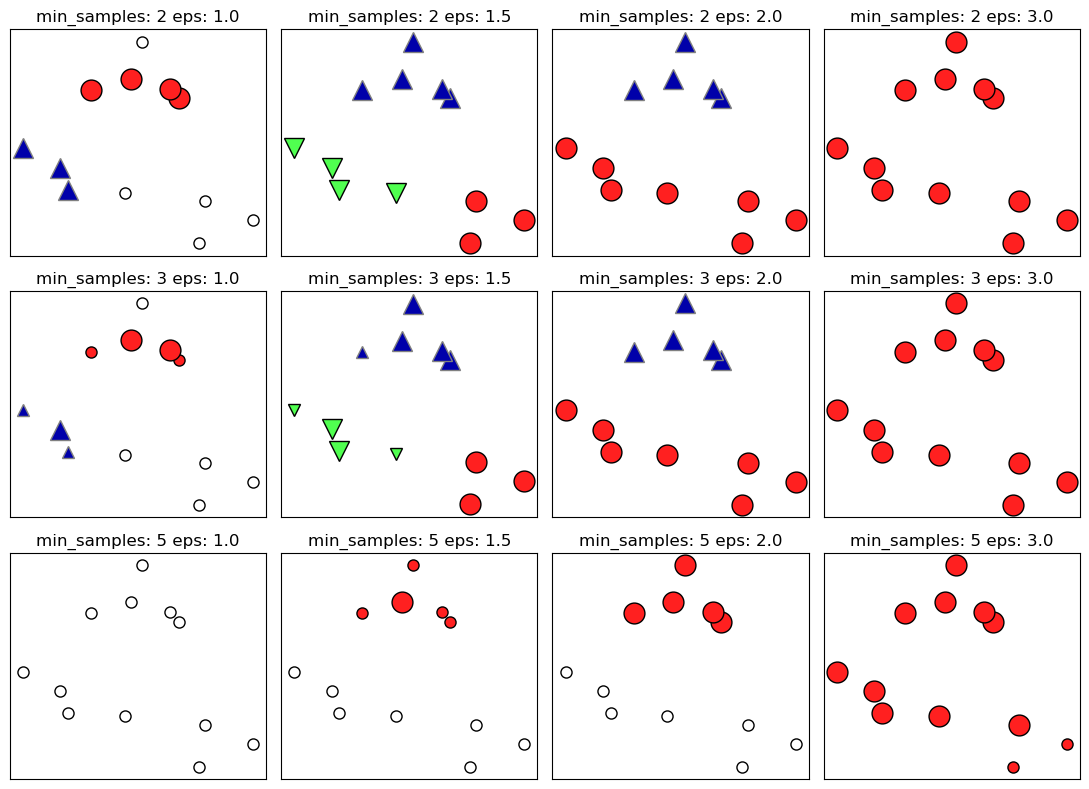

In [41]:
mglearn.plots.plot_dbscan()